# RPS tracking

This notebook shows the full RPS-tracking loop: pull a recording span, examine it, run a neural predictor from the zoo, and run the blind DSP tracking ladder on the same audio. Each step is one or two calls into the library (`plots.explore`, `plots.dwym`, `zoo`, `tracking`).

In [10]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
for p in (ROOT, ROOT / "src"):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

import numpy as np
import tdseries as td
import matplotlib.pyplot as plt

from plots import dwym, explore

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1 · Datasets

`explore.datasets()` lists every published dataset pinned in `dload.lock`. Pass `sizes=True` for sample counts (fetches manifests).

In [11]:
explore.datasets()

,name,version
0,AVQ,50dd53d1a6c0
1,AVQ-egonoise,b43b374b007a
2,AVQ-egonoise-vkrps,266f5241bfb0
3,AVQ-raw,0e17e52b16c3
4,AeroSonicDB,0d5543419ea5
5,DN-LM-train,4576c1679b3b
6,DN-LM-valid,f6e7038600b9
7,DREGON,db39bcf762d0
8,DREGON-LM-V2-train,8a81bf7b7b5d
9,DREGON-LM-V2-valid,1eb8384871be


## 2 · Pull a recording span

The data cells stream from R2. This guard fails early, with a clear message, when credentials are missing.

In [4]:
import os

import data_processing.streams  # noqa: F401 — loads the .env credentials

if not os.environ.get("AWS_ACCESS_KEY_ID"):
    raise RuntimeError(
        "No R2 credentials. The cells below stream dload datasets. "
        "Fill .env at the repo root (see docs/data-and-artifacts.md), then rerun."
    )

In [50]:
import torch, torch.nn.functional as F
import zoo
from experiments import rps_bench as rb
from pathlib import Path
from plots.rps_prediction.full_sequence import plot_full_sequence

def plot_overlay(o):
    plot_full_sequence(
        audio=np.asarray(o["audio"].data).squeeze(),
        rps_gt=np.asarray(o["rps"].data),          # (4, T_gt)
        rps_pred=np.asarray(o["rps_pred"].data),   # (4, T), already PIT-aligned; the plot re-aligns, harmless
        sr=16000,
        title=f"{o['meta']['flight']} mic {o['meta']['channel']}  MAE {o['meta']['mae']:.2f}",
        figsize=(15, 8)
    )

## 3 · A neural predictor from the zoo

`zoo.checkpoints` lists trained experiments from the R2 artifact store (cached locally). `zoo.load` returns the model as one Frame → Frame callable.

In [32]:
hppnet_l2 = zoo.load('hppnet_l2_r2_s0')

In [36]:
hppnet_l2.model.superres_head.net[6].weight.shape

torch.Size([4, 32, 1, 1])

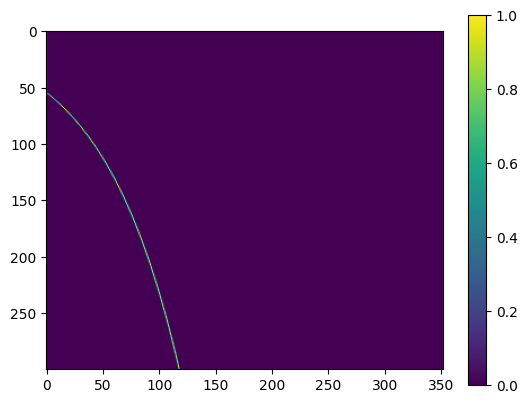

In [28]:
plt.imshow(hppnet_l2.model.superres_head.W)
plt.colorbar()
plt.show()

/home/flyingleafe/Research/PhD/projects/harmonic-noise-suppression/src/plots/rps_prediction/full_sequence.py:159: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


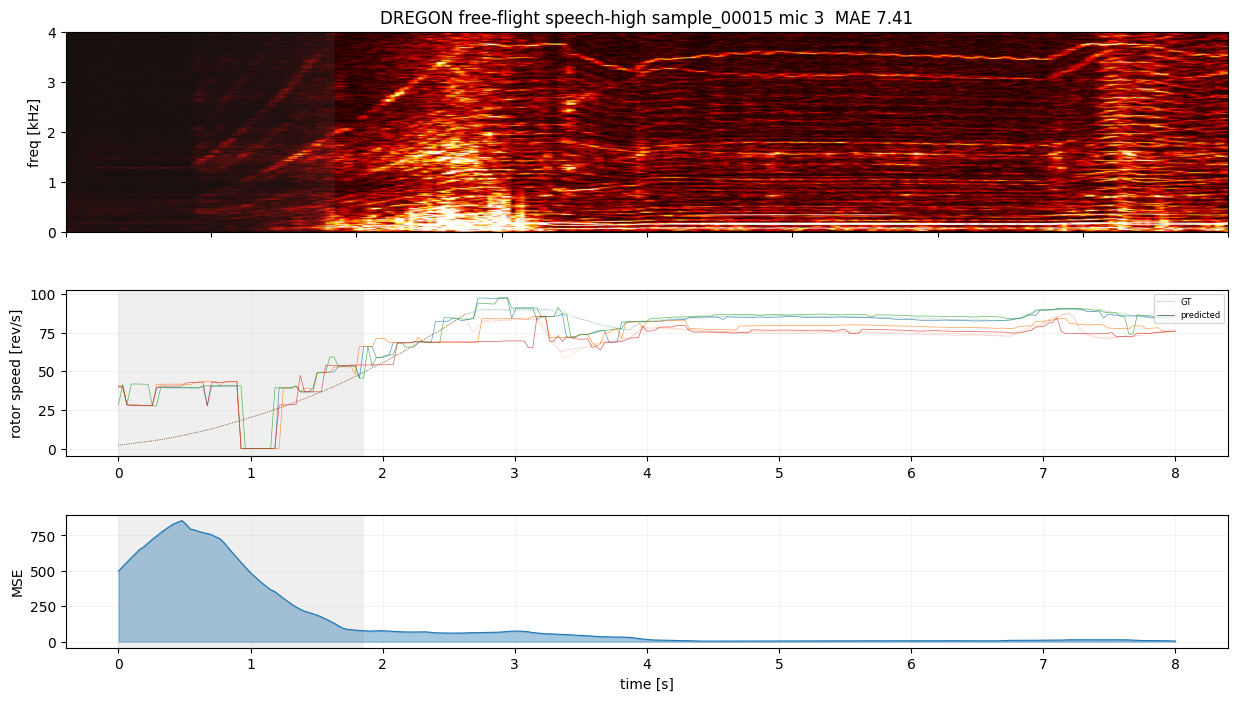

In [58]:
B = Path("results/paper_review_B/hppnet_l2_r2_s0")
#for clip in (1, 8, 15, 22, 35):
clip=15
plot_overlay(rb.overlay("hppnet_l2_r2_s0", "real", clip*8 + 3, dump_root=B))

/home/flyingleafe/Research/PhD/projects/harmonic-noise-suppression/src/plots/rps_prediction/full_sequence.py:159: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


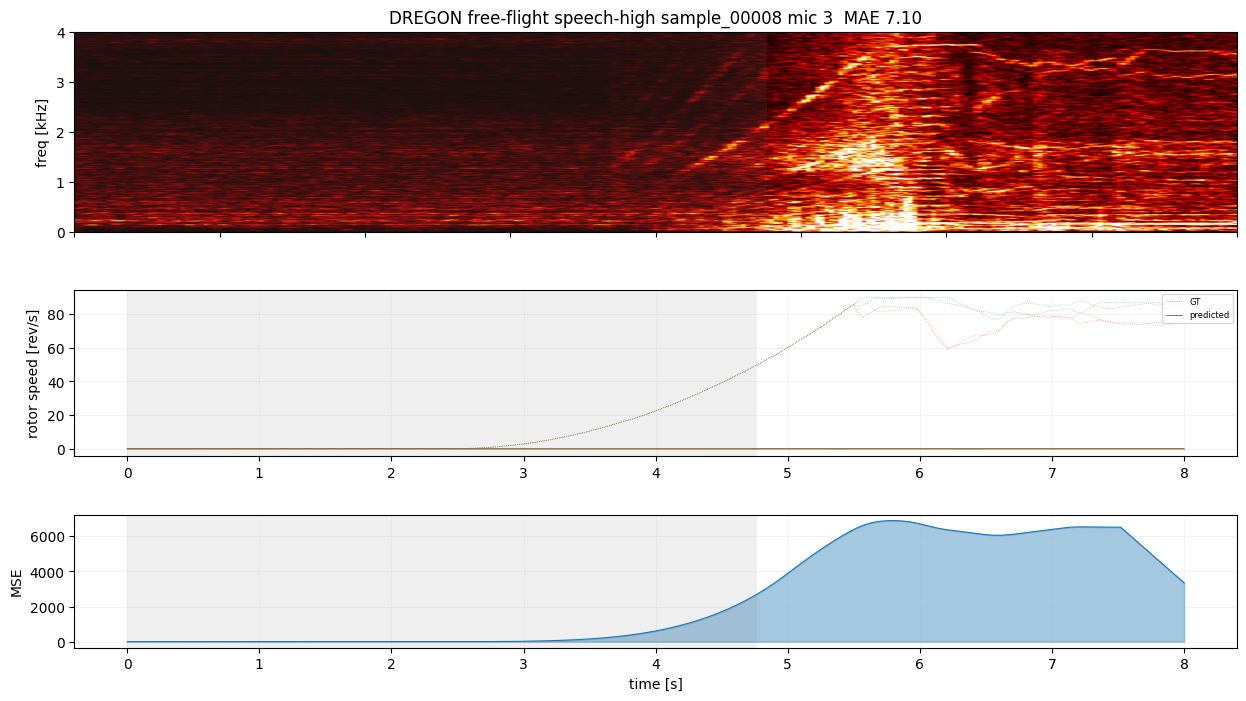

In [55]:
B = Path("results/paper_review_B/hb_sal_multif0_l4")
#for clip in (1, 8, 15, 22, 35):
clip=8
plot_overlay(rb.overlay("hb_sal_multif0_l4", "real", clip*8 + 3, dump_root=B))

## 4 · The blind DSP tracking ladder

Tracking stages are `td.Frame → td.Frame` callables (`tracking.stages`). `blind_seed_stage` finds the base speeds; the guarded VK stage captures and refines the trajectories. For the full calibrated annotation ladder, use `tracking.vit2dsp_stage`.

In [51]:
import tracking as trk

tf = td.Frame({"audio": audio16, "rps_meas": clip["rps"], "meta": td.Frame({})})
ladder = trk.pipeline(trk.blind_seed_stage(4), trk.guarded(trk.vk_stage(trk.CAPTURE_CFG)))
tracked = ladder(tf)  # roughly a minute on CPU for 8 s of audio

Overlay the tracked trajectories on the telemetry the same way.

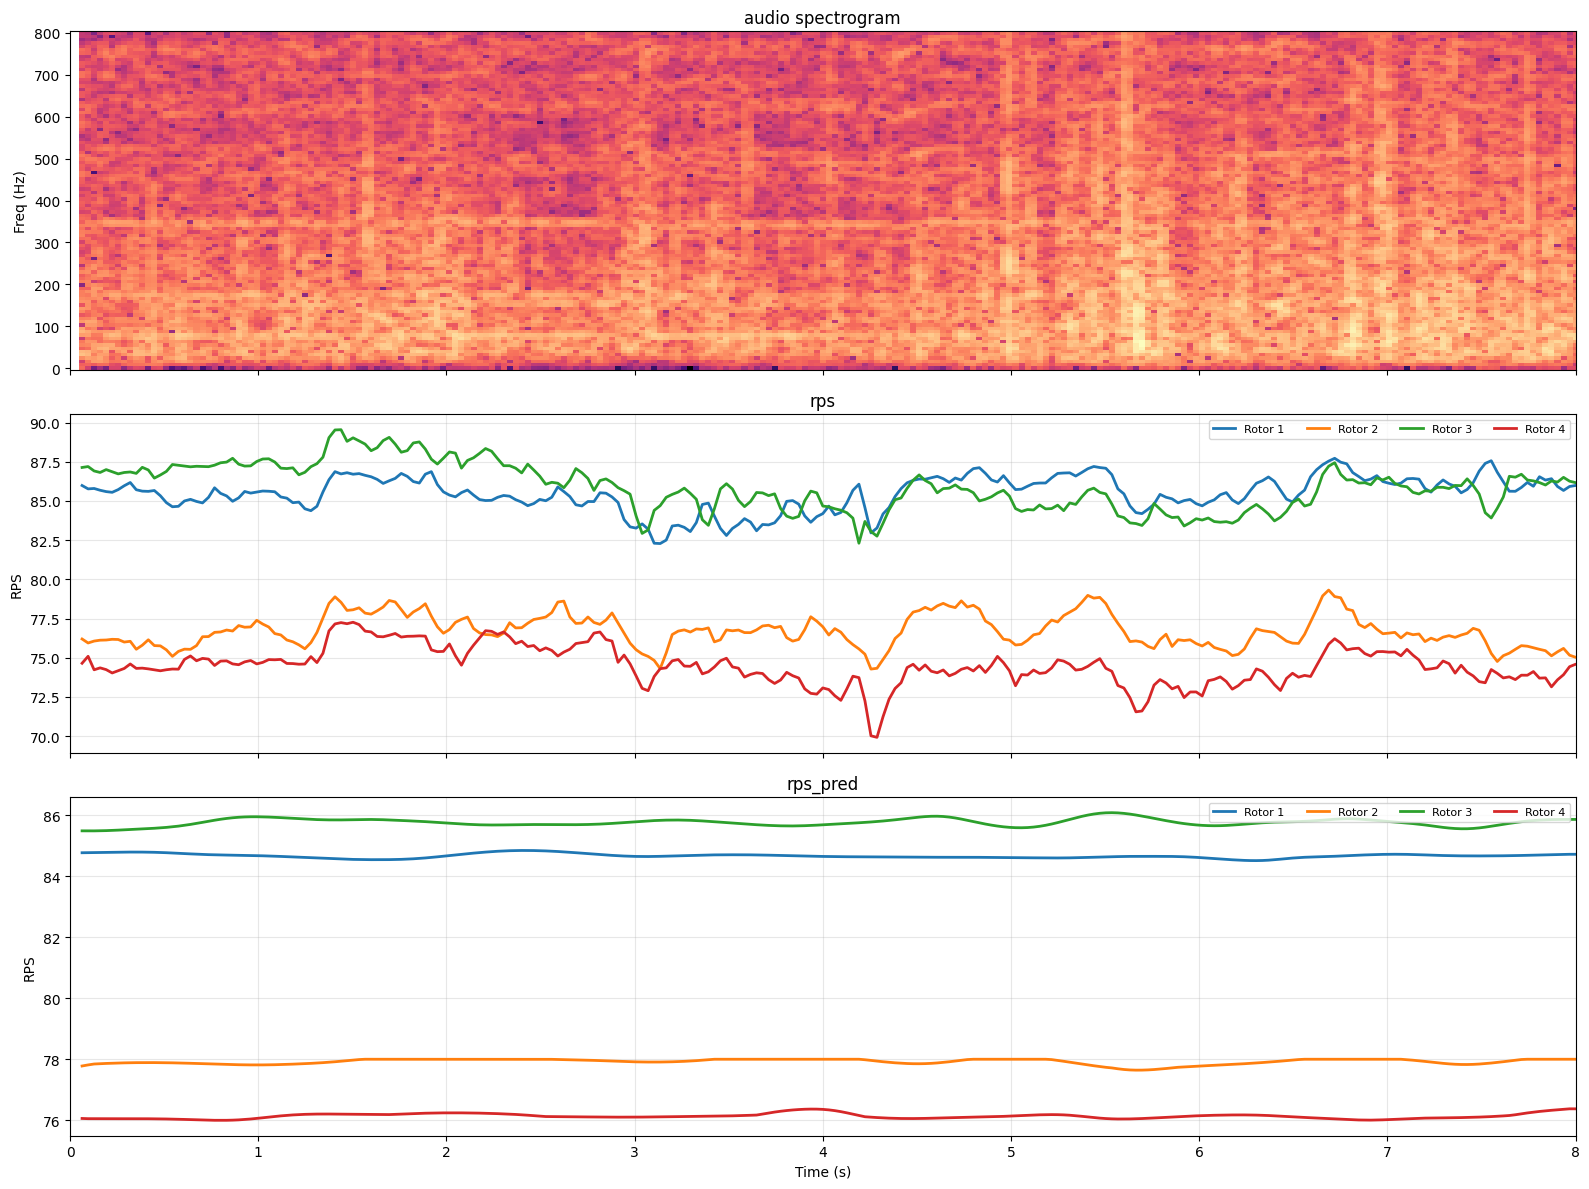

audio


In [52]:
overlay = td.Frame({"audio": audio16, "rps": clip["rps"], "rps_pred": tracked["rps"]})
dwym(overlay, fmax=800)

## 5 · The tracking log

Every stage appends one diagnostics dict to `meta["tracking"]`.

In [ ]:
for entry in tracked["meta"]["tracking"]:
    info = {k: v for k, v in entry.items() if k != "stage"}
    print(f"{entry['stage']:12s} {info}")

## 6 · Any predictor on the benchmark parts, side by side

Three parts, the same for every model (`experiments.rps_bench.PARTS`): the salv2 static comb (`comb`), the salv2 stochastic comb (`stoch`) and the real full-envelope split (`real`), plus the speech twins `comb_speech` / `stoch_speech`. A frame is one microphone of an 8 s clip: frame `i` of a synthetic part is flight `i // 8`, mic `i % 8`.

Predictions come from the dump `results/rps_dump/` (27 checkpoints, `scripts/rps_dump.py`) when it holds the experiment, else from the checkpoint through `zoo.load` on the CPU (`source="live"` forces that; any `zoo` experiment works). A part is synthesized once and pickled under `.cache/rps_bench/`; `real` needs R2 credentials. `rb.worst` reads `results/rps_profile/frames.csv` (`scripts/rps_error_profile.py`), so the failures are one call away.

In [ ]:
from experiments import rps_bench as rb

rb.experiments()  # what the dump holds; any other zoo experiment runs live

In [ ]:
rb.worst("real", "hppnet_r4_l4")  # the frames worth a look: index, flight, mic, PIT MAE, error class

In [ ]:
# several models on ONE frame: spectrogram, label, one PIT-aligned row per model
f = rb.compare(["hppnet_r4_l4", "r4hb_scv2", "m3mixv2_unigru128"], "real", 71)
rb.show(f, fmax=2000);

In [ ]:
# ONE model across the parts: dwym takes a {label: overlay} dict and aligns the blocks
dwym({p: rb.overlay("salv2_hppnet_stoch_nomix", p, 8) for p in ("comb", "stoch", "real")}, fmax=2000)

In [ ]:
# a model the dump does not hold (or a fresh checkpoint): the same call, run live on the CPU
dwym(rb.overlay("salv2_hppnet_comb_nomix", "comb", 19 * 8 + 3, source="live"), fmax=2000)

Next steps: `docs/notebook-primitives-tutorial.md` walks each primitive, `src/tracking/AGENTS.md` documents the stage API, and `notebooks/AGENTS.md` maps the other notebooks.